In [27]:
!ls -lh dataset.zip

-rw-r--r-- 1 root root 541M Sep 19 05:58 dataset.zip
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
!unzip -q dataset.zip -d dataset


replace dataset/dataset/COVID/images/COVID-1.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


Step 1 : Data Exploration

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image

In [30]:
dataset_path = "dataset/dataset"
classes = ["COVID", "Normal", "Viral Pneumonia"]

In [32]:
counts = []
for class_name in classes:
    folder = os.path.join(dataset_path, class_name, "images" )
    counts.append(len(os.listdir(folder)))


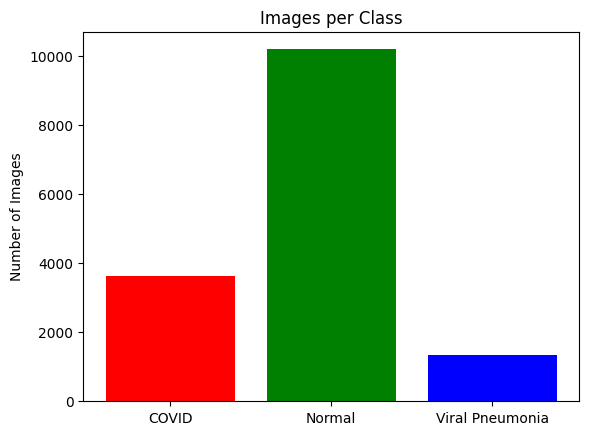

In [33]:
plt.bar(classes, counts, color= ['red', 'green', 'blue'])
plt.title("Images per Class")
plt.ylabel("Number of Images")
plt.show()

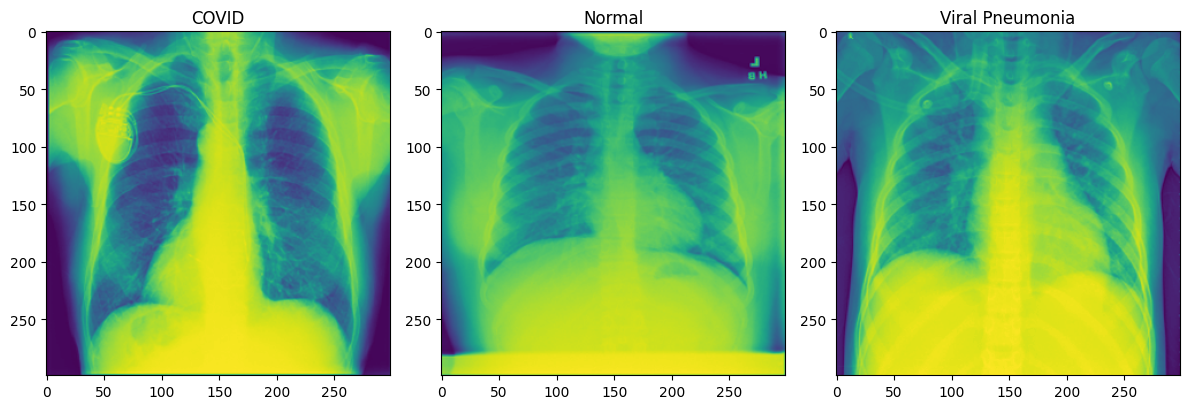

In [34]:
plt.figure(figsize = (12, 4))
for i, class_name in enumerate(classes):
        folder = os.path.join(dataset_path, class_name, "images" )
        filename = os.listdir(folder)[0]
        full_path = os.path.join(folder, filename)
        image = PIL.Image.open(full_path)
        plt.subplot(1,3, i + 1)
        plt.imshow(image)
        plt.title(class_name)
plt.tight_layout()
plt.show()

 Step 2: Data Loading (PyTorch Dataset, Transforms & DataLoader)

In [35]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from glob import glob

In [36]:
class_to_idx = {"COVID": 0, "Normal": 1, "Viral Pneumonia": 2}

class ChestXRayDataset(Dataset):
    def __init__(self, image_paths, labels, transforms = None):
        self.image_paths = image_paths
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = PIL.Image.open(img_path).convert('RGB')

        if self.transforms:
            image = self.transforms(image)

        return image, torch.tensor(label, dtype=torch.long)

Step 2.1: Collecting Image Paths & Labels


In [37]:
all_image_paths = []
all_labels = []

for class_name, label_idx in class_to_idx.items():
   pattern = os.path.join(dataset_path, class_name,"images", "*.png")
   img_paths = glob(pattern)

   all_image_paths.extend(img_paths)

   all_labels.extend([label_idx] * len(img_paths))

print(f"Total images collected: {len(all_image_paths)}")
print(f"Total labels collected: {len(all_labels)}")

Total images collected: 15153
Total labels collected: 15153


In [38]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std= [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean= [0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transforms defined successfully!")

Transforms defined successfully!


Step 2.3: Train / Validation / Test Splitting

In [39]:
from sklearn.model_selection import train_test_split

train_paths, temp_paths, train_labels, temp_labels = train_test_split(all_image_paths, all_labels, test_size=0.30,random_state=42, stratify=all_labels )
val_paths, test_paths, val_labels, test_labels = train_test_split(temp_paths, temp_labels, test_size= 0.50, random_state= 42, stratify=temp_labels)

print(f"Train Samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")
print(f"Test Samples: {len(test_paths)}")

Train Samples: 10607
Validation samples: 2273
Test Samples: 2273


Step 2.4: Creating Datasets & DataLoaders


In [40]:
#Data Loading
train_dataset = ChestXRayDataset(train_paths, train_labels, transforms=train_transforms)
val_dataset = ChestXRayDataset(val_paths, val_labels, transforms= val_test_transforms)
test_dataset = ChestXRayDataset(test_paths, test_labels, transforms=val_test_transforms)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

sample_images, sample_labels =next(iter(train_loader))
print(f"Batch image shape: {sample_images.shape}")
print(f"Batch label shape: {sample_labels.shape}")

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])


Step 3: The CNN Backbone (Feature Extractor)


In [41]:
class CNNBackbone(nn.Module):
    def __init__(self):
        super(CNNBackbone, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

        )

    def forward(self, x):
        return self.features(x)

test_cnn = CNNBackbone()
dummy_input = torch.randn(2,3,224,224)
dummy_output = test_cnn(dummy_input)
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {dummy_output.shape}")

Input shape: torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 512, 7, 7])


Step 4 & 5: Transformer Encoder & The Full Hybrid Model


In [42]:
class ChestDiseaseModel(nn.Module):
    def __init__(self, num_classes=3, d_model=512, nhead=8, num_transformer_layers=2):
        super(ChestDiseaseModel, self).__init__()

        self.cnn = CNNBackbone()

        self.pos_embedding = nn.Parameter(torch.randn(1, 49, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model = d_model,
            nhead = nhead,
            dim_feedforward = 1024,
            dropout = 0.1,
            batch_first=True

        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        features = self.cnn(x)

        batch_size, channels, h, w = features.shape
        tokens = features.flatten(2).transpose(1,2)

        tokens = tokens + self.pos_embedding

        trans_out = self.transformer(tokens)

        pooled = trans_out.mean(dim=1)

        logits = self.classifier(pooled)
        return logits


model = ChestDiseaseModel()
dummy_x = torch.randn(2,3,224,224)
output_logits = model(dummy_x)

print(f"Input batch shape:  {dummy_x.shape}")
print(f"Output logits shape: {output_logits.shape}")
print(f"Sample raw logits: \n{output_logits}")


Input batch shape:  torch.Size([2, 3, 224, 224])
Output logits shape: torch.Size([2, 3])
Sample raw logits: 
tensor([[-0.0729, -0.0051, -0.0965],
        [-0.0445,  0.0635, -0.1164]], grad_fn=<AddmmBackward0>)


Step 6: Training Pipeline (Class Weights, Optimizer, & Training Loop)

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class_counts = [3616, 10192, 1345]
total_samples = sum(class_counts)
num_classes = len(class_counts)

weights = [total_samples / (num_classes * count) for count in class_counts]
class_weights = torch.tensor(weights, dtype = torch.float).to(device)

print(f"\nComputed Class Weights:")
for c_name, w in zip(classes, weights):
    print(f"  {c_name}: {w:.3f}")


model = ChestDiseaseModel(num_classes=3).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode= 'min', factor=0.5, patience=2)

print("\nModel, Loss Function, and Optimizer initialized successfully!")

Using device: cuda

Computed Class Weights:
  COVID: 1.397
  Normal: 0.496
  Viral Pneumonia: 3.755

Model, Loss Function, and Optimizer initialized successfully!



Step 6.2: The Training & Validation Loop

In [ ]:
import time
import copy

EPOCHS = 20 

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_loss = float('inf')

print(f"Starting Training on {device} for {EPOCHS} epochs...\n" + "="*50)

for epoch in range(EPOCHS):
    start_time = time.time()

  # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    running_corrects= 0
    total_train = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels.data).item()
        total_train += labels.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects / total_train


    # --- VALIDATION PHASE ---
    model.eval()
    val_loss = 0.0
    val_corrects = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * images.size(0)
            val_corrects += torch.sum(preds == labels.data).item()
            total_val += labels.size(0)

    epoch_val_loss = val_loss / total_val
    epoch_val_acc = val_corrects / total_val

    scheduler.step(epoch_val_loss)

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    elapsed = time.time() - start_time

    print(f"Epoch [{epoch+1}/{EPOCHS}] ({elapsed:.1f}s) | " f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc*100:.2f}% | " f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc*100:.2f}%")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        print(f" --> Saved new best model with Val Loss: {best_val_loss:.4f}")

model.load_state_dict(best_model_wts)
print("="*50 + f"\nTraining Complete! Best Val Loss: {best_val_loss:.4f}")



0

Starting Training on cuda for 20 epochs...
Epoch [1/20] (81.9s) | Train Loss: 0.5500 - Train Acc: 69.86% | Val Loss: 0.4442 - Val Acc: 65.07%
 --> Saved new best model with Val Loss: 0.4442
Epoch [2/20] (74.6s) | Train Loss: 0.3252 - Train Acc: 83.42% | Val Loss: 0.2938 - Val Acc: 80.91%
 --> Saved new best model with Val Loss: 0.2938
Epoch [3/20] (75.4s) | Train Loss: 0.2560 - Train Acc: 87.81% | Val Loss: 0.1848 - Val Acc: 93.40%
 --> Saved new best model with Val Loss: 0.1848
Epoch [4/20] (75.3s) | Train Loss: 0.2060 - Train Acc: 90.29% | Val Loss: 0.2143 - Val Acc: 93.22%
Epoch [5/20] (74.0s) | Train Loss: 0.1835 - Train Acc: 91.65% | Val Loss: 0.1384 - Val Acc: 95.42%
 --> Saved new best model with Val Loss: 0.1384
Epoch [6/20] (73.3s) | Train Loss: 0.1661 - Train Acc: 92.48% | Val Loss: 0.1155 - Val Acc: 95.42%
 --> Saved new best model with Val Loss: 0.1155
Epoch [7/20] (74.5s) | Train Loss: 0.1518 - Train Acc: 93.16% | Val Loss: 0.1278 - Val Acc: 95.12%
Epoch [8/20] (73.7s) | T

0

Step 7: Evaluation (Confusion Matrix, Per-Class Precision/Recall, Learning Curves)

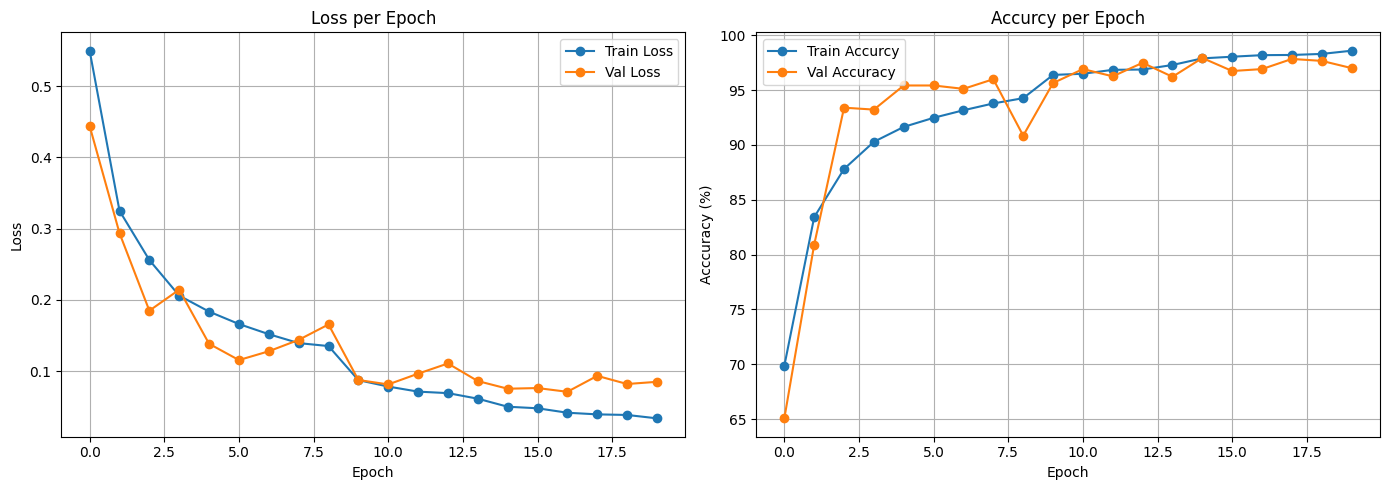

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

#Plot loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label= 'Val Loss', marker='o')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

#Plot Accuracy
axes[1].plot([a *100 for a in history['train_acc']], label= 'Train Accurcy', marker='o')
axes[1].plot([a * 100 for a in history['val_acc']], label= 'Val Accuracy', marker='o')
axes[1].set_title('Accurcy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Acccuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Classification Report:

                 precision    recall  f1-score   support

          COVID       0.94      0.99      0.96       543
         Normal       0.99      0.97      0.98      1529
Viral Pneumonia       0.91      0.99      0.95       201

       accuracy                           0.97      2273
      macro avg       0.95      0.98      0.96      2273
   weighted avg       0.97      0.97      0.97      2273



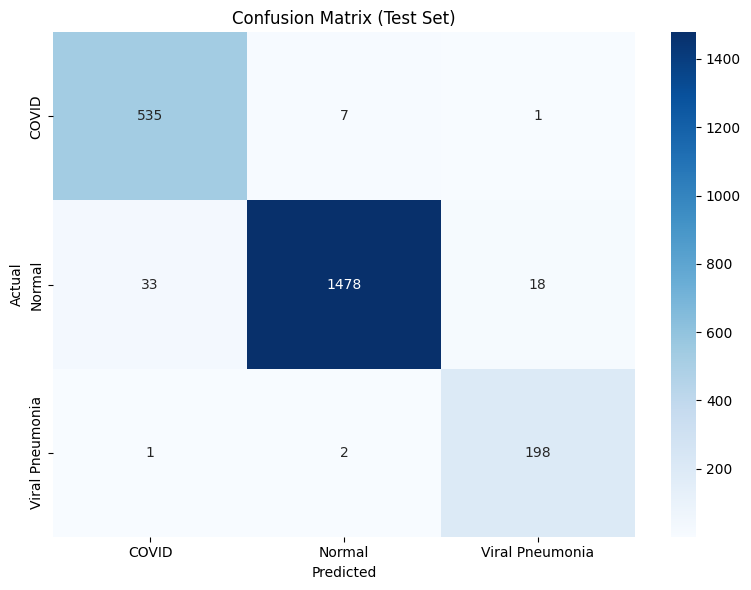

In [46]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.numpy())

print("Classification Report:\n")
print(classification_report(all_true, all_preds, target_names=classes))

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt= 'd', cmap= 'Blues',xticklabels=classes,yticklabels=classes)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

Step 8: Save Model Weights and Class Metadata


In [ ]:

save_dict = {
    'model_state_dict': model.state_dict(),
    'classes': classes,
    'class_to_idx':class_to_idx
}

torch.save(save_dict,"chest_disease_model.pth")
print("Saved PyTorch checkpoint: chest_disease_model.pth")


Saved PyTorch checkpoint: chest_disease_model.pth


Step 9: Verify Loading & Test Single Image Inference

In [49]:
import torch
from PIL import  Image

infer_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

loaded_model = ChestDiseaseModel(num_classes=3).to(infer_device)

checkpoint = torch.load("chest_disease_model.pth",map_location=infer_device)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()
print("Model loaded and verified successfully!")


def predict_image(image_path, model, transform, classes):
    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(infer_device)

    with torch.no_grad():
        outputs = model(tensor)
        probabilties = torch.softmax(outputs, dim=1)[0]
        confidence, predicted_idx = torch.max(probabilties, 0)

    predicted_class = classes[predicted_idx.item()]
    return predicted_class, confidence.item() * 100, probabilties.cpu().numpy()

sample_test_path = test_paths[0]
pred_class, conf, all_probs = predict_image(sample_test_path, loaded_model, val_test_transforms, classes)

print(f"\nSample Image: {sample_test_path}")
print(f"PredictedCondition: {pred_class} ({conf:.2f}% confidence)")
for c_name, prob in zip(classes, all_probs):
    print(f" {c_name}: {prob*100:.2f}%")

Model loaded and verified successfully!

Sample Image: dataset/dataset/Viral Pneumonia/images/Viral Pneumonia-976.png
PredictedCondition: Viral Pneumonia (99.98% confidence)
 COVID: 0.01%
 Normal: 0.01%
 Viral Pneumonia: 99.98%
